# 04 Spectral Graph Methods
## Laplacian Eigenanalysis for Fraud Detection

### Mathematical Foundation

**Graph Laplacian:**
$$L = D - A \qquad \mathcal{L} = D^{-1/2} L D^{-1/2}$$

**Eigenvalues:** $0 = \lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n \leq 2$

| Quantity | Meaning | Fraud Relevance |
|----------|---------|-----------------|
| $\lambda_2$ (Fiedler value) | Algebraic connectivity | Small -> easy to split -> fraud community separation |
| Fiedler vector | Optimal graph bisection | Fraud nodes partition differently |
| Spectral gap $\lambda_3 - \lambda_2$ | Community strength | Large gap -> k natural clusters |

### Bridge to GCN
Chebyshev polynomial approximation of spectral convolution:
$$g_\theta * x \approx \sum_{k=0}^{K} \theta_k T_k(\tilde{L})x$$
Setting K=1 gives the **GCN layer** (Notebook 05).


In [1]:
# ============================================================
# Google Colab Setup -- Run this cell FIRST every session
# ============================================================
import os, sys, glob

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Roots ────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/fraudDataset"
PROJECT_ROOT = f"{DRIVE_ROOT}/Fraud-Detection-GT"

# Add project src/ to Python path so we can import from src/
sys.path.insert(0, PROJECT_ROOT)

# ── Dataset Paths ─────────────────────────────────────────────
CC_PATH  = f"{DRIVE_ROOT}/creditcard/creditcard.csv"
LEIE_PATH = f"{DRIVE_ROOT}/leie/UPDATED.csv"

# Medicare: 3 separate yearly files (auto-detect names)
MED_DIR = f"{DRIVE_ROOT}/medicare"
MED_FILES = sorted(glob.glob(f"{MED_DIR}/*.csv"))  # finds all CSVs

# ── Output Paths (on Drive  →  survive session restarts) ─────
OUTPUTS_DIR = f"{PROJECT_ROOT}/outputs"
FIGURES_DIR = f"{PROJECT_ROOT}/outputs/figures"
METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
MODELS_DIR  = f"{PROJECT_ROOT}/outputs/models"
GRAPHS_DIR  = f"{PROJECT_ROOT}/data/graphs"

# ML baseline pickles (optional -- upload Fraud-Detection project too)
ML_PICKLES_DIR = f"{DRIVE_ROOT}/Fraud-Detection/pickled_storage"

# Create output directories (idempotent)
for _d in [OUTPUTS_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, GRAPHS_DIR,
           f"{GRAPHS_DIR}/credit_card", f"{GRAPHS_DIR}/medicare"]:
    os.makedirs(_d, exist_ok=True)

# Load config.yaml
import yaml
_cfg_path = f"{PROJECT_ROOT}/config.yaml"
CONFIG = {}
if os.path.exists(_cfg_path):
    with open(_cfg_path) as _f:
        CONFIG = yaml.safe_load(_f)

# ── Status Report ─────────────────────────────────────────────
print("=" * 58)
print("  Fraud Detection GT  |  Colab + Drive Environment")
print("=" * 58)
print(f"  Project Root  : {PROJECT_ROOT}")
print(f"  Credit Card   : {CC_PATH}")
print(f"  LEIE file     : {LEIE_PATH}")
print(f"  Medicare files: {len(MED_FILES)} found in {MED_DIR}")
for _f in MED_FILES:
    print(f"    - {os.path.basename(_f)}")
print()
print(f"  Outputs       : {OUTPUTS_DIR}")
print()

# Verify
_ok = True
for _path, _label in [(CC_PATH, "creditcard/creditcard.csv"),
                       (LEIE_PATH, "leie/UPDATED.csv")]:
    if os.path.exists(_path):
        _mb = os.path.getsize(_path)/1e6
        print(f"  [OK]  {_label} ({_mb:.0f} MB)")
    else:
        print(f"  [!!]  {_label} NOT FOUND")
        _ok = False

if len(MED_FILES) == 0:
    print("  [!!]  No Medicare CSVs found in medicare/")
    _ok = False
elif len(MED_FILES) < 3:
    print(f"  [??]  Only {len(MED_FILES)} Medicare file(s) found (expected 3)")
else:
    total_mb = sum(os.path.getsize(f)/1e6 for f in MED_FILES)
    print(f"  [OK]  medicare/ ({len(MED_FILES)} files, {total_mb:.0f} MB total)")

print()
print("  Ready!" if _ok else "  WARNING: Some files missing -- check Drive paths above")
print("=" * 58)


Mounted at /content/drive
  Fraud Detection GT  |  Colab + Drive Environment
  Project Root  : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT
  Credit Card   : /content/drive/MyDrive/fraudDataset/creditcard/creditcard.csv
  LEIE file     : /content/drive/MyDrive/fraudDataset/leie/UPDATED.csv
  Medicare files: 3 found in /content/drive/MyDrive/fraudDataset/medicare
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv

  Outputs       : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs

  [OK]  creditcard/creditcard.csv (151 MB)
  [OK]  leie/UPDATED.csv (15 MB)
  [OK]  medicare/ (3 files, 11921 MB total)

  Ready!


In [2]:
import numpy as np, pandas as pd, networkx as nx
import scipy.sparse as sp, scipy.sparse.linalg as spla
import matplotlib.pyplot as plt, matplotlib, time, json
import warnings; warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor':'#0F0F1A','axes.facecolor':'#1A1A2E',
    'text.color':'#EEEEFF','axes.labelcolor':'#CCCCEE',
    'xtick.color':'#CCCCEE','ytick.color':'#CCCCEE',
})

from src.graph_builder import load_graph
from src.graph_features import compute_laplacian, compute_spectral_features, spectral_clustering_labels
from sklearn.metrics import roc_auc_score, average_precision_score

G_cc  = load_graph(f'{GRAPHS_DIR}/credit_card/G_cc_knn.pkl')
G_med = load_graph(f'{GRAPHS_DIR}/medicare/G_med_provider.pkl')
print(f"Graphs loaded from Drive")
print(f"   CC:  {G_cc.number_of_nodes():,} nodes | {G_cc.number_of_edges():,} edges")
print(f"   Med: {G_med.number_of_nodes():,} nodes | {G_med.number_of_edges():,} edges")


Graphs loaded from Drive
   CC:  50,000 nodes | 347,127 edges
   Med: 7,701 nodes | 113,350 edges


---
## 1. Laplacian Eigenvalue Spectrum

In [3]:
print("Computing spectral features Credit Card...")
t0 = time.time()
spec_cc = compute_spectral_features(G_cc, n_eigenvectors=30)
print(f"  Done in {time.time()-t0:.1f}s")

print("\nComputing spectral features Medicare...")
t0 = time.time()
spec_med = compute_spectral_features(G_med, n_eigenvectors=30)
print(f"  Done in {time.time()-t0:.1f}s")


Computing spectral features Credit Card...
[Spectral] Computing 30 eigenvectors for 50000 nodes...
[Spectral] Fiedler value (algebraic connectivity): 0.000619
[Spectral] Spectral gap: 0.011899
  Done in 3.0s

Computing spectral features Medicare...
[Spectral] Computing 30 eigenvectors for 7701 nodes...
[Spectral] Fiedler value (algebraic connectivity): 0.013493
[Spectral] Spectral gap: 0.080487
  Done in 0.3s


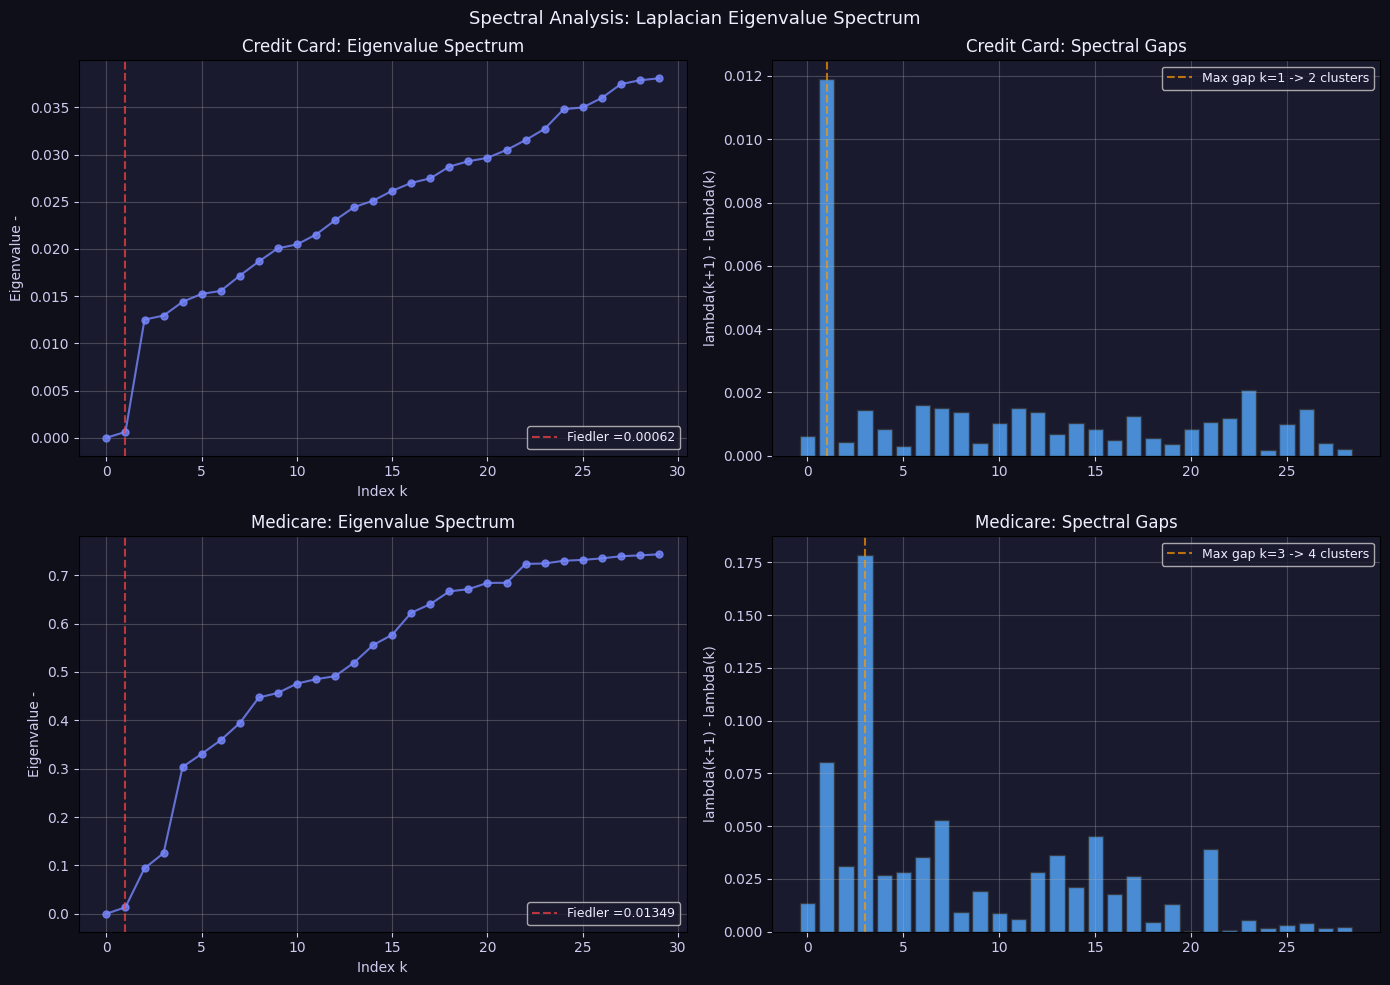

In [9]:
# Eigenvalue spectrum plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spectral Analysis: Laplacian Eigenvalue Spectrum', fontsize=13, color='#EEEEFF')

for row, (spec, name) in enumerate([(spec_cc,'Credit Card'), (spec_med,'Medicare')]):
    evals = spec['eigenvalues']
    gaps  = np.diff(evals)

    # Spectrum
    ax = axes[row, 0]
    ax.plot(evals, 'o-', color='#7788FF', markersize=5, alpha=0.8)
    ax.axvline(1, color='#FF4444', linestyle='--', alpha=0.7,
               label=f"Fiedler ={spec['fiedler_value']:.5f}")
    ax.set_xlabel('Index k'); ax.set_ylabel('Eigenvalue -')
    ax.set_title(f'{name}: Eigenvalue Spectrum')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Gaps
    ax = axes[row, 1]
    ax.bar(range(len(gaps)), gaps, color='#55AAFF', alpha=0.8, edgecolor='#333')
    max_k = np.argmax(gaps)
    ax.axvline(max_k, color='#FF9900', linestyle='--', alpha=0.7,
               label=f"Max gap k={max_k} -> {max_k+1} clusters")
    ax.set_ylabel('lambda(k+1) - lambda(k)')
    ax.set_title(f'{name}: Spectral Gaps')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/spectral_eigenvalues.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Fiedler Vector â€” Fraud Topology Detection

The Fiedler vector bisects the graph optimally. Nodes with positive values -> community A;
negative -> community B. If fraud concentrates on one side: strong structural signal.


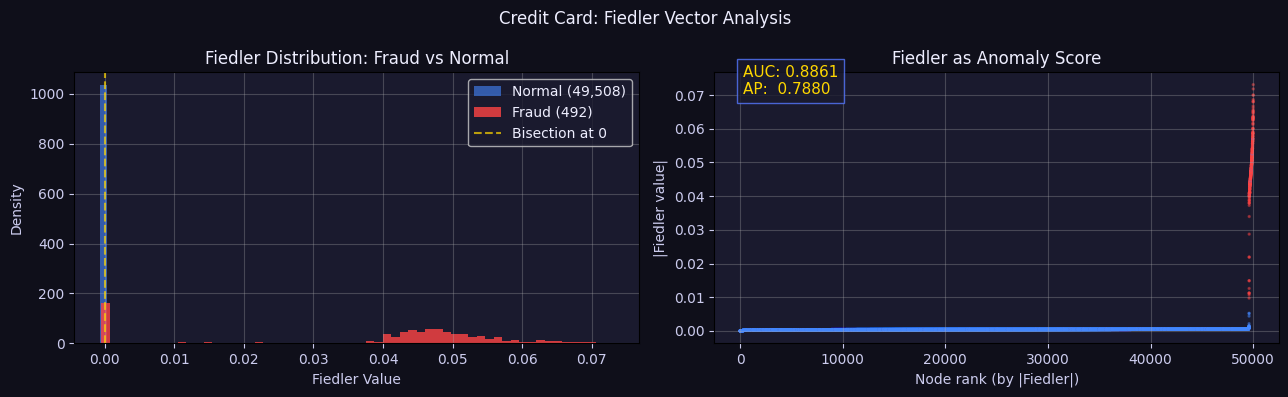

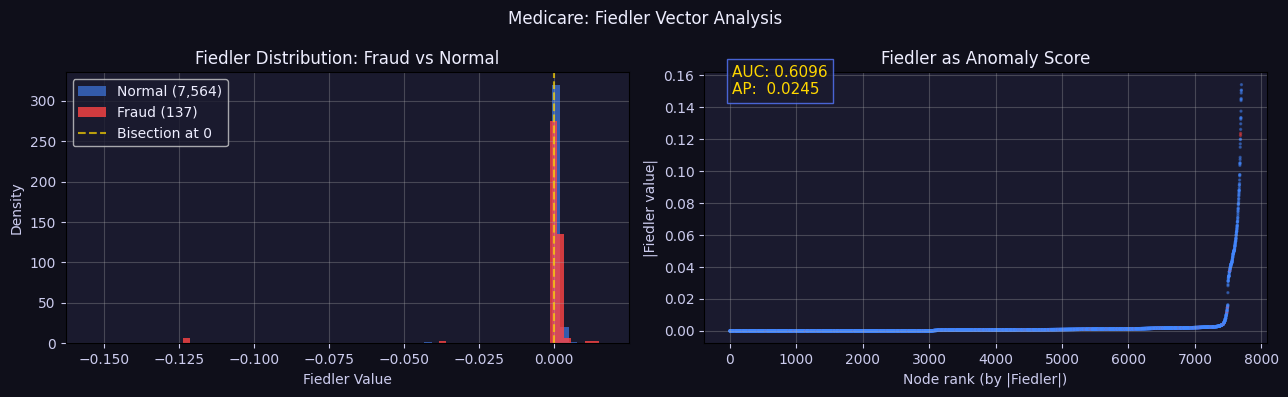

In [5]:
spectral_results = []

def analyze_fiedler(G, spec, name):
    fv = spec['fiedler_vector']
    node_order = spec['node_order']
    if fv is None:
        print(f"{name}: Fiedler vector not available"); return None

    labels = np.array([G.nodes[n].get('label',0) for n in node_order])
    fraud_fv  = fv[labels==1]
    normal_fv = fv[labels==0]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{name}: Fiedler Vector Analysis', fontsize=12, color='#EEEEFF')

    ax = axes[0]
    ax.hist(normal_fv, bins=60, alpha=0.6, color='#4488FF',
            label=f'Normal ({len(normal_fv):,})', density=True)
    if len(fraud_fv)>0:
        ax.hist(fraud_fv, bins=60, alpha=0.8, color='#FF4444',
                label=f'Fraud ({len(fraud_fv):,})', density=True)
    ax.axvline(0, color='#FFD700', linestyle='--', alpha=0.7, label='Bisection at 0')
    ax.set_xlabel('Fiedler Value'); ax.set_ylabel('Density')
    ax.set_title('Fiedler Distribution: Fraud vs Normal')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    anomaly = np.abs(fv)
    if len(fraud_fv)>0:
        auc = roc_auc_score(labels, anomaly)
        ap  = average_precision_score(labels, anomaly)
        ax.text(0.05, 0.92, f'AUC: {auc:.4f}\nAP:  {ap:.4f}',
                transform=ax.transAxes, fontsize=11, color='#FFD700',
                bbox=dict(facecolor='#1A1A2E', edgecolor='#5577FF', alpha=0.8))
        spectral_results.append({
            'dataset': name, 'category': 'Graph-Spectral',
            'method': 'Fiedler_Anomaly',
            'auc_roc': auc, 'auc_prc': ap, 'f1': None
        })
    ax.scatter(range(len(anomaly)), np.sort(anomaly),
               c=['#FF4444' if l==1 else '#4488FF'
                  for l in labels[np.argsort(anomaly)]],
               s=2, alpha=0.4)
    ax.set_xlabel('Node rank (by |Fiedler|)'); ax.set_ylabel('|Fiedler value|')
    ax.set_title('Fiedler as Anomaly Score'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/{name.lower().replace(" ","_")}_fiedler.png',
                dpi=150, bbox_inches='tight')
    plt.show()

analyze_fiedler(G_cc,  spec_cc,  'Credit Card')
analyze_fiedler(G_med, spec_med, 'Medicare')


---
## 3. Spectral Clustering as Fraud Detection

Use k eigenvectors -> K-Means clustering -> measure fraud concentration per cluster.


  Credit Card: SpectralClustering k=10 -> AUC:0.9221 | AP:0.7489


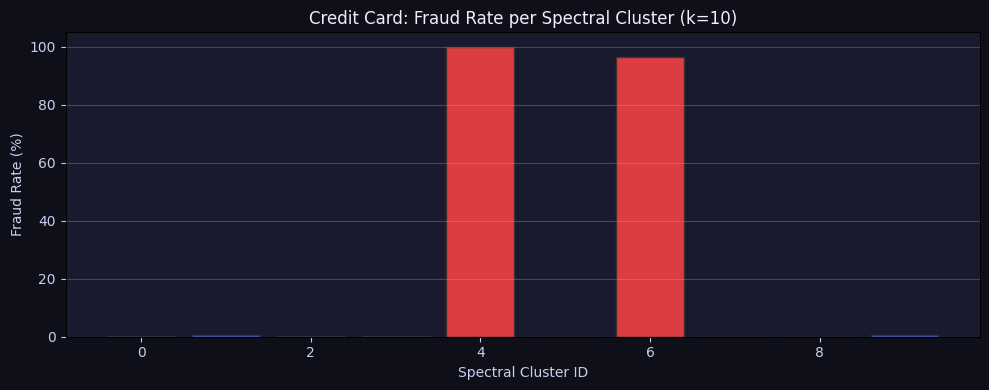

  Medicare: SpectralClustering k=10 -> AUC:0.5779 | AP:0.0251


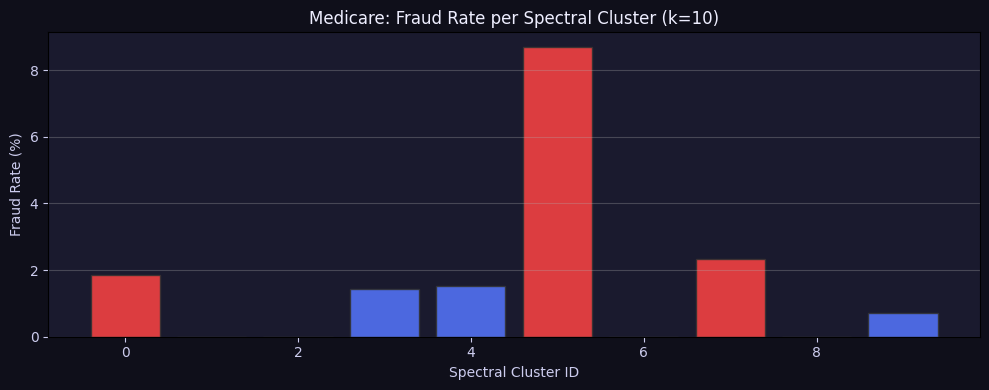


âœ… Spectral results saved to Drive


In [11]:
from sklearn.cluster import KMeans

def spectral_fraud_cluster(G, spec, dataset_name, n_clusters=10):
    node_order = spec['node_order']
    labels = np.array([G.nodes[n].get('label',0) for n in node_order])
    if labels.sum()==0:
        print(f"  {dataset_name}: No fraud labels skipping"); return

    evecs = spec['eigenvectors'][:, 1:n_clusters+1]
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = km.fit_predict(evecs)

    # Each cluster's fraud rate -> anomaly score
    fraud_rates = {c: labels[cluster_ids==c].mean() for c in range(n_clusters)}
    anomaly_scores = np.array([fraud_rates.get(c,0) for c in cluster_ids])
    anomaly_scores += np.linalg.norm(evecs - km.cluster_centers_[cluster_ids], axis=1)

    auc = roc_auc_score(labels, anomaly_scores)
    ap  = average_precision_score(labels, anomaly_scores)
    print(f"  {dataset_name}: SpectralClustering k={n_clusters} -> AUC:{auc:.4f} | AP:{ap:.4f}")

    spectral_results.append({
        'dataset': dataset_name, 'category': 'Graph-Spectral',
        'method': f'SpectralClustering_k{n_clusters}',
        'auc_roc': auc, 'auc_prc': ap, 'f1': None
    })

    # Visualize
    fig, ax = plt.subplots(figsize=(10,4))
    fr_vals = [fraud_rates[c]*100 for c in sorted(fraud_rates)]
    colors  = ['#FF4444' if r>np.mean(fr_vals) else '#5577FF' for r in fr_vals]
    ax.bar(range(n_clusters), fr_vals, color=colors, alpha=0.85, edgecolor='#333')
    ax.set_xlabel('Spectral Cluster ID'); ax.set_ylabel('Fraud Rate (%)')
    ax.set_title(f'{dataset_name}: Fraud Rate per Spectral Cluster (k={n_clusters})')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/{dataset_name.lower().replace(" ","_")}_spectral_clusters.png',
                dpi=150, bbox_inches='tight')
    plt.show()

spectral_fraud_cluster(G_cc,  spec_cc,  'Credit Card', n_clusters=10)
spectral_fraud_cluster(G_med, spec_med, 'Medicare',    n_clusters=10)

with open(f'{METRICS_DIR}/spectral_results.json', 'w') as f:
    json.dump(spectral_results, f, indent=2, default=str)
print("\nâœ Spectral results saved to Drive")


---
## 4. Chebyshev Polynomial -> GCN Bridge

Spectral convolution approximated by Chebyshev polynomials $T_k(\tilde{L})$:

$$T_0 = x, \quad T_1 = \tilde{L}x, \quad T_2 = 2\tilde{L}T_1 - T_0, \quad \ldots$$

**Setting K=1** gives the GCN layer we'll train in Notebook 05:
$$H^{(l+1)} = \sigma\!\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H^{(l)} W^{(l)}\right)$$


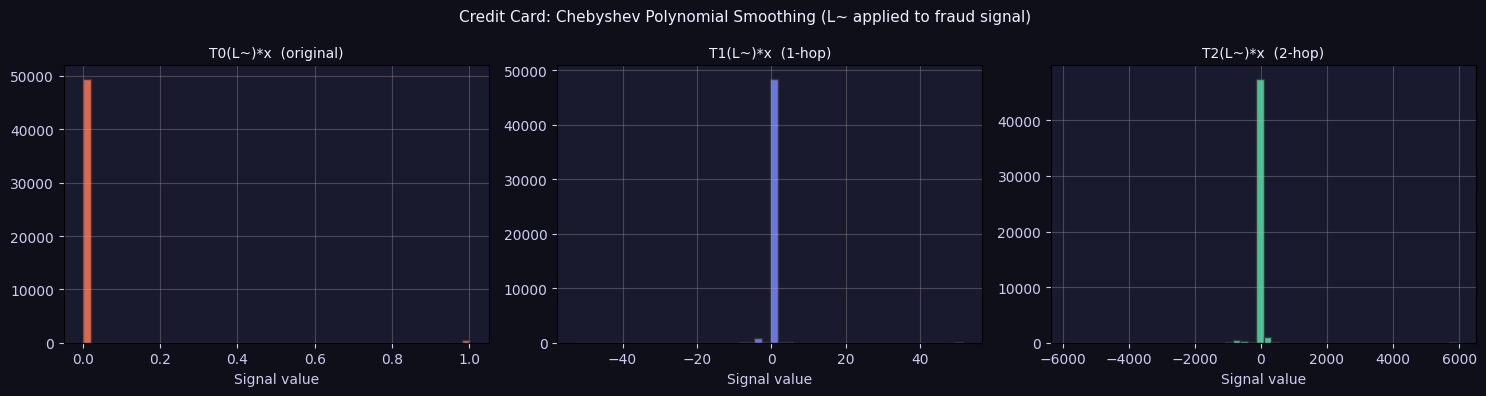

Credit Card: T2 smoothing complete -> This is GCN's 2-layer operation!


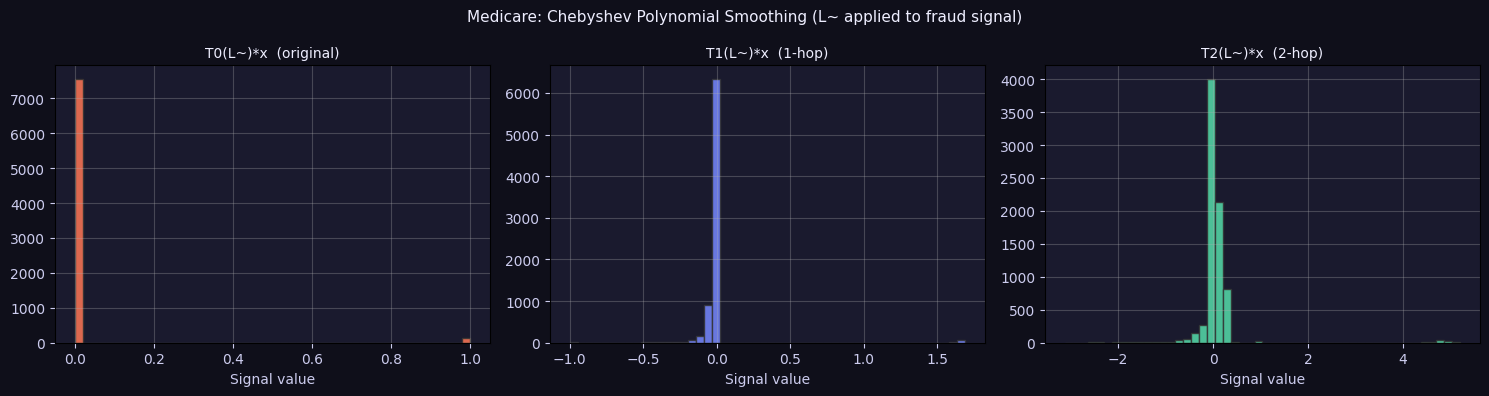

Medicare: T2 smoothing complete -> This is GCN's 2-layer operation!
  NOTEBOOK 04 - COMPLETE
  Credit Card    |Fiedler_Anomaly: AUC=0.8861
  Medicare       |Fiedler_Anomaly: AUC=0.6096
  Credit Card    |SpectralClustering_k10: AUC=0.9221
  Medicare       |SpectralClustering_k10: AUC=0.5779
  Next -> 05_GNN_Models.ipynb


In [10]:
def chebyshev_demo(G, spec, name):
    L = compute_laplacian(G, normalized=True)
    node_order = spec['node_order']
    n = len(node_order)
    x = np.array([G.nodes[nd].get('label',0) for nd in node_order], dtype=float)

    l_max = spec['eigenvalues'][-1] if len(spec['eigenvalues'])>0 else 2.0
    L_tilde = L*(2.0/l_max) - sp.eye(n, format='csr')

    T0 = x.copy()
    T1 = L_tilde @ x
    T2 = 2 * L_tilde @ T1 - T0

    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(f'{name}: Chebyshev Polynomial Smoothing (L~ applied to fraud signal)',
                  fontsize=11, color='#EEEEFF')
    for ax, (t,lbl,col) in zip(axes, [(T0,'T0(L~)*x  (original)','#FF7755'),
                                       (T1,'T1(L~)*x  (1-hop)','#7788FF'),
                                       (T2,'T2(L~)*x  (2-hop)','#55DDAA')]):
        ax.hist(t, bins=50, color=col, alpha=0.85, edgecolor='#333')
        ax.set_title(lbl, fontsize=10); ax.set_xlabel('Signal value')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/{name.lower().replace(" ","_")}_chebyshev.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{name}: T2 smoothing complete -> This is GCN's 2-layer operation!")

chebyshev_demo(G_cc,  spec_cc,  'Credit Card')
chebyshev_demo(G_med, spec_med, 'Medicare')

print("=" * 55)
print("  NOTEBOOK 04 - COMPLETE")
print("=" * 55)
for r in spectral_results:
    print(f"  {r['dataset']:<15}|{r['method']}: AUC={r['auc_roc']:.4f}")
print("  Next -> 05_GNN_Models.ipynb")
print("=" * 55)
